# Comparación de clasificadores — dataset DNU (v2)

Construye un dataset unificado donde cada columna es la predicción binaria **0/1** (0 = no odio, 1 = odio) de cada clasificador sobre los tweets del corpus DNU 70/2017.

---

## Clasificadores incluidos

### HATEFUL — etiqueta manual (gold standard)
Etiquetado manual realizado por el equipo de PIUBA-bigdata usando [piuba-bigdata/beto-contextualized-hate-speech](https://huggingface.co/piuba-bigdata/beto-contextualized-hate-speech).  
Cada tweet puede tener una o más categorías: `CALLS`, `WOMEN`, `LGBTI`, `RACISM`, `CLASS`, `POLITICS`, `DISABLED`, `APPEARANCE`, `CRIMINAL`.  
**`HATEFUL = 1`** si el tweet tiene al menos una categoría *excepto* `CALLS` (que refiere a llamados a acción, no necesariamente discurso de odio).

### GPT — GPT-4o vía Batch API
Clasificación zero-shot con GPT-4o usando la Batch API de OpenAI. La variable `gpt_is_xenophobic` es `True`/`False` y se mapea directamente a `1`/`0`.

### Cardiff — `cardiffnlp/twitter-xlm-roberta-base-hate-spanish`
XLM-RoBERTa fine-tuneado en hate speech en Twitter en español por el grupo CardiffNLP.  
Etiquetas originales: `HATE` / `NOT-HATE`. **`Cardiff = 1`** si `HATE`.

### BNE — `JonatanGk/roberta-base-bne-finetuned-hate-speech-offensive-spanish`
RoBERTa fine-tuneado con datos del Biblioteca Nacional de España (BNE).  
Etiquetas originales: `HATE` / `OFFENSIVE` / `NEITHER`. **`BNE = 1`** si `HATE` u `OFFENSIVE`.

### BETO — `delarosajav95/HateSpeech-BETO-cased-v2`
BETO (BERT en español) fine-tuneado para detección de odio con cobertura de varias formas de discriminación.  
Etiquetas originales: `LABEL_1` (odio) / `LABEL_0`. **`BETO = 1`** si `LABEL_1`.

### pysentimiento — RoBERTuito hate speech
Modelo basado en [RoBERTuito](https://huggingface.co/pysentimiento/roberta-hate-speech-spanish) de la librería `pysentimiento`.  
Devuelve una lista de categorías detectadas: `hateful`, `targeted`, `aggressive`. **`pysentimiento = 1`** si la lista no está vacía.  
> ⚠️ Cobertura parcial: solo las primeras 58 534 filas (2021-03-05). El resto es `NaN`.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)

## 2. Configuración

In [2]:
# Archivos de entrada
FILE_BASE = 'data/tweets_dnu_clasificados.csv'
FILE_GPT  = 'data/DNU_gpt_xenofobia.csv'
FILE_HF   = 'data/DNU_modelos_hf.csv'
FILE_PYS  = 'data/DNU_pysentiment.csv'

# Categorías manuales que definen HATEFUL (se excluye CALLS)
HATE_COLS = ['WOMEN', 'LGBTI', 'RACISM', 'CLASS', 'POLITICS', 'DISABLED', 'APPEARANCE', 'CRIMINAL']

# Nombre corto de cada modelo en el dataset final
MODEL_NAMES = ['HATEFUL', 'GPT', 'Cardiff', 'BNE', 'BETO', 'pysentimiento']

## 3. Carga y construcción del dataset unificado

In [3]:
# ── Base ─────────────────────────────────────────────────────────────────────
df_base = pd.read_csv(FILE_BASE, low_memory=False, usecols=
    ['id', 'text', 'fecha', 'fecha_dia'] + HATE_COLS)

df_base['HATEFUL'] = df_base[HATE_COLS].any(axis=1).astype(int)

# ── GPT ──────────────────────────────────────────────────────────────────────
df_gpt = pd.read_csv(FILE_GPT, usecols=['batch_is_xenophobic'])
df_gpt['GPT'] = pd.to_numeric(df_gpt['batch_is_xenophobic'], errors='coerce').astype('Int64')

# ── HuggingFace ───────────────────────────────────────────────────────────────
df_hf = pd.read_csv(FILE_HF, usecols=[
    'cardiff_xlm_hate_es__binary_pred',
    'bne_hate_offensive_es__binary_pred',
    'beto_hate_v2_es__binary_pred',
]).rename(columns={
    'cardiff_xlm_hate_es__binary_pred':    'Cardiff',
    'bne_hate_offensive_es__binary_pred':  'BNE',
    'beto_hate_v2_es__binary_pred':        'BETO',
})

# ── pysentimiento (cobertura parcial) ─────────────────────────────────────────
df_pys = pd.read_csv(FILE_PYS, usecols=['pysentimiento_hate__binary_pred'])
df_pys_full = (
    df_pys
    .rename(columns={'pysentimiento_hate__binary_pred': 'pysentimiento'})
    .reindex(range(len(df_base)))  # filas sin cobertura → NaN
)

# ── Unificación posicional ─────────────────────────────────────────────────────
df = pd.concat([
    df_base[['id', 'text', 'fecha', 'fecha_dia', 'HATEFUL']],
    df_gpt[['GPT']],
    df_hf[['Cardiff', 'BNE', 'BETO']],
    df_pys_full[['pysentimiento']],
], axis=1)

print(f"Dataset unificado: {df.shape[0]:,} filas x {df.shape[1]} columnas")
df.head(5)

Dataset unificado: 259,752 filas x 10 columnas


,id,text,fecha,fecha_dia,HATEFUL,GPT,Cardiff,BNE,BETO,pysentimiento
0,1367792447334580225,RT @CELS_Argentina: ✅Celebramos la decisión del Poder Ejecutivo de derogar e...,2021-03-05 11:01:46+00:00,2021-03-05,0,0,0,0,0,0.0
1,1367793643239702529,RT @LANACION: Ley de Migraciones: el Gobierno derogó el decreto de Mauricio ...,2021-03-05 11:06:31+00:00,2021-03-05,0,0,0,0,0,0.0
2,1367793651192070144,"RT @CRLDEMONIO: Y lo peor , el alto mando de @Carabdechile *NO LO APOYÓ* ...",2021-03-05 11:06:33+00:00,2021-03-05,0,0,0,0,0,0.0
3,1367793655092813824,RT @elcarpo: El Gobierno derogó el decreto de Mauricio Macri que impedía el ...,2021-03-05 11:06:34+00:00,2021-03-05,0,0,0,0,0,0.0
4,1367793655029764101,"@joseantoniokast @sebastianpinera yo voté por @sebastianpinera, \ny estoy en...",2021-03-05 11:06:34+00:00,2021-03-05,0,0,0,0,0,0.0


## 4. Cobertura por clasificador

In [4]:
n_total = len(df)
rows = []
for m in MODEL_NAMES:
    n_cov  = int(df[m].notna().sum())
    n_hate = int((df[m] == 1).sum())
    rows.append({
        'Clasificador':      m,
        'Tweets cubiertos':  n_cov,
        '% cobertura':       f"{n_cov / n_total * 100:.1f}%",
        'Tweets odiosos':    n_hate,
        '% odio (cubiertos)': f"{n_hate / n_cov * 100:.1f}%" if n_cov else '-',
    })

pd.DataFrame(rows).set_index('Clasificador')

,Tweets cubiertos,% cobertura,Tweets odiosos,% odio (cubiertos)
Clasificador,,,,
HATEFUL,259752,100.0%,15567,6.0%
GPT,259752,100.0%,44344,17.1%
Cardiff,259752,100.0%,30856,11.9%
BNE,259752,100.0%,76798,29.6%
BETO,259752,100.0%,18130,7.0%
pysentimiento,58534,22.5%,10355,17.7%


## 5. % de hate por clasificador

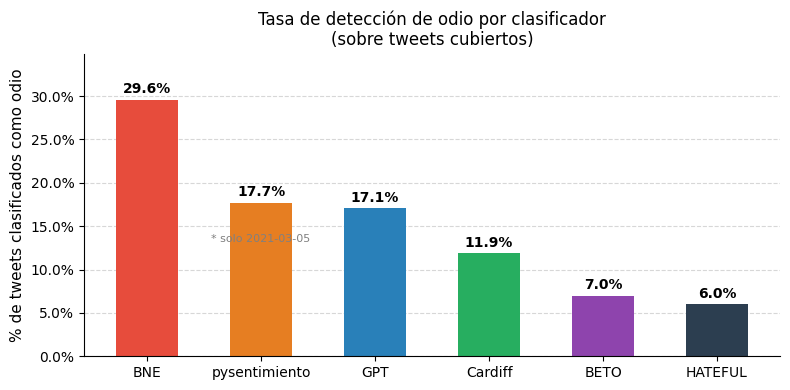

In [5]:
# Calcular % hate sobre tweets cubiertos por cada modelo
hate_pct = {}
for m in MODEL_NAMES:
    covered = df[m].notna()
    hate_pct[m] = (df.loc[covered, m] == 1).mean() * 100

labels = list(hate_pct.keys())
values = list(hate_pct.values())

# Ordenar de mayor a menor
order  = sorted(range(len(values)), key=lambda i: values[i], reverse=True)
labels = [labels[i] for i in order]
values = [values[i] for i in order]

COLORS = {
    'HATEFUL':       '#2c3e50',
    'GPT':           '#2980b9',
    'Cardiff':       '#27ae60',
    'BNE':           '#e74c3c',
    'BETO':          '#8e44ad',
    'pysentimiento': '#e67e22',
}
bar_colors = [COLORS[l] for l in labels]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(labels, values, color=bar_colors, width=0.55, zorder=2)

# Etiquetas encima de cada barra
for bar, val in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.4,
        f"{val:.1f}%",
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

ax.set_ylabel('% de tweets clasificados como odio', fontsize=11)
ax.set_title('Tasa de detección de odio por clasificador\n(sobre tweets cubiertos)', fontsize=12)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set_ylim(0, max(values) * 1.18)
ax.grid(axis='y', linestyle='--', alpha=0.5, zorder=1)
ax.spines[['top', 'right']].set_visible(False)

# Nota para pysentimiento si cobertura parcial
if df['pysentimiento'].notna().sum() < n_total:
    ax.annotate(
        '* solo 2021-03-05',
        xy=(labels.index('pysentimiento'), hate_pct['pysentimiento']),
        xytext=(0, -28), textcoords='offset points',
        ha='center', fontsize=8, color='gray'
    )

plt.tight_layout()
plt.savefig('outputs/hate_pct_por_clasificador.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Tweets odiosos por modelo y por día

In [12]:
# Total tweets por día (denominador)
tweets_por_dia = df.groupby('fecha_dia').size().rename('total_tweets')

# Conteo de hate=1 por día para cada modelo
daily_hate = df.groupby('fecha_dia')[MODEL_NAMES].apply(lambda g: (g == 1).sum())

# Agregar total de tweets
daily_hate.insert(0, 'total_tweets', tweets_por_dia)

print("Cantidad de tweets odiosos por modelo y por día:")
display(daily_hate)

# Tasa: % de hate por día (sobre total de tweets del día)
daily_rate = daily_hate[MODEL_NAMES].div(daily_hate['total_tweets'], axis=0) * 100
daily_rate = daily_rate.round(2)

print("\n% de tweets odiosos por modelo y por día:")
display(daily_rate)

Cantidad de tweets odiosos por modelo y por día:


,total_tweets,HATEFUL,GPT,Cardiff,BNE,BETO,pysentimiento
fecha_dia,,,,,,,
2021-03-05,106851,4297,26148,11444,26451,8405,10355
2021-03-06,80224,6287,12748,9544,22577,5736,0
2021-03-07,37339,2561,3327,4444,13357,1807,0
2021-03-08,35160,2406,2112,5383,14324,2171,0
2021-03-09,178,16,9,41,89,11,0



% de tweets odiosos por modelo y por día:


,HATEFUL,GPT,Cardiff,BNE,BETO,pysentimiento
fecha_dia,,,,,,
2021-03-05,4.02,24.47,10.71,24.76,7.87,9.69
2021-03-06,7.84,15.89,11.90,28.14,7.15,0.00
2021-03-07,6.86,8.91,11.90,35.77,4.84,0.00
2021-03-08,6.84,6.01,15.31,40.74,6.17,0.00
2021-03-09,8.99,5.06,23.03,50.00,6.18,0.00


## 7. Hilos con más respuestas odiosas

Se usan las **respuestas** (`in_reply_to_status_id`) en lugar de RTs: cada respuesta tiene texto propio y distinto, evitando el problema de contenido repetido.

Se filtran los grupos con al menos 1 respuesta etiquetada como `HATEFUL=1` o `RACISM=1` por el clasificador manual contextual (piuba-bigdata/beto). Del pool de candidatos se eligen hilos al azar con semilla controlable.

> El tweet original (padre del hilo) no está en el dataset — se muestra su ID y un enlace a Twitter.  
> Cambiar `SEED` para ver distintos hilos del mismo pool.

In [20]:
import html as htmllib
from IPython.display import display, HTML

# ── Configuración ─────────────────────────────────────────────────────────────
SEED      = 76    # ← cambiar para explorar distintos hilos
N_THREADS = 5     # hilos a mostrar
N_REPLIES = 7     # respuestas por hilo
POOL      = 50    # candidatos desde donde samplear
FILTRO_MANUAL = 'HATEFUL'  # 'HATEFUL' o 'RACISM'

MODEL_COLORS = {
    'HATEFUL':       ('#2c3e50', 'Original-BETO'),
    'GPT':           ('#2980b9', 'GPT'),
    'Cardiff':       ('#27ae60', 'Cardiff'),
    'BNE':           ('#e74c3c', 'BNE'),
    'BETO':          ('#8e44ad', 'BETO'),
    'pysentimiento': ('#e67e22', 'pysent.'),
}

# ── 1. Cargar etiquetas manuales individuales y merge ─────────────────────────
extra = pd.read_csv(
    FILE_BASE,
    usecols=['id', 'in_reply_to_status_id', 'RACISM'],
    low_memory=False,
)
df_rep = df.merge(extra, on='id', how='left')

# ── 2. Filtrar replies y construir grupos ─────────────────────────────────────
replies = df_rep[df_rep['in_reply_to_status_id'].notna()].copy()
replies['_parent'] = pd.to_numeric(replies['in_reply_to_status_id'], errors='coerce').astype('Int64').astype(str)

grp_stats = (
    replies.groupby('_parent')
    .agg(n_total   = ('id',           'count'),
         n_hateful = (FILTRO_MANUAL,  'sum'))
    .reset_index()
    .query('n_hateful >= 1')
    .sort_values('n_hateful', ascending=False)
    .head(POOL)
)

selected = grp_stats.sample(min(N_THREADS, len(grp_stats)), random_state=SEED).reset_index(drop=True)

print(f"Grupos candidatos con ≥1 reply {FILTRO_MANUAL}: {len(grp_stats)}")
print(f"Mostrando {len(selected)} hilos con SEED={SEED}\n")
display(selected.rename(columns={
    '_parent':   'parent_tweet_id',
    'n_total':   'replies_totales',
    'n_hateful': f'replies_{FILTRO_MANUAL}',
}))

# ── 3. Funciones de render ─────────────────────────────────────────────────────
def _badges(row):
    parts = []
    for col, (color, label) in MODEL_COLORS.items():
        try:
            if col in row.index and pd.notna(row[col]) and int(row[col]) == 1:
                parts.append(
                    f'<span style="background:{color};color:#fff;padding:2px 8px;'
                    f'border-radius:10px;font-size:11px;margin-right:3px;">{label}</span>'
                )
        except Exception:
            pass
    return ''.join(parts) or '<span style="color:#aaa;font-size:11px;">—</span>'

def _reply_card(row):
    text   = htmllib.escape(str(row['text'])[:400])
    date   = str(row.get('fecha_dia', ''))[:10]
    badges = _badges(row)
    return (
        f'<div style="background:#fff;border:1px solid #dde;border-radius:8px;'
        f'padding:10px 14px;margin:5px 0;">'
        f'  <div style="background:#fff;font-size:11px;color:#999;margin-bottom:5px;">💬 {date}</div>'
        f'  <div style="background:#fff;font-size:13px;color:#222;line-height:1.5;margin-bottom:7px;">{text}</div>'
        f'  <div style="background:#fff;">{badges}</div>'
        f'</div>'
    )

def _thread_html(parent_id, n_total, n_hateful, reply_rows):
    url          = f'https://twitter.com/i/status/{parent_id}'
    replies_html = ''.join(_reply_card(r) for _, r in reply_rows.iterrows())
    return (
        f'<div style="font-family:Arial,sans-serif;border:2px solid #2c3e50;'
        f'border-radius:10px;margin-bottom:28px;overflow:hidden;">'
        f'  <div style="background:#2c3e50;color:#fff;padding:10px 16px;'
        f'display:flex;justify-content:space-between;align-items:center;">'
        f'    <span style="font-weight:bold;font-size:13px;">Tweet original '
        f'      <a href="{url}" target="_blank" style="color:#7fb3d3;font-size:11px;margin-left:6px;">'
        f'        #{parent_id} ↗</a></span>'
        f'    <span style="font-size:11px;opacity:.75;">'
        f'      {n_total} respuestas &nbsp;·&nbsp; {n_hateful} {FILTRO_MANUAL}</span>'
        f'  </div>'
        f'  <div style="background:#f0f2f5;padding:8px 16px;font-size:12px;'
        f'color:#666;border-bottom:1px solid #dde;font-style:italic;">'
        f'    Contenido no disponible en el dataset — ver enlace ↗</div>'
        f'  <div style="background:#fff;padding:10px 12px;">'
        f'    <div style="background:#fff;font-size:11px;color:#666;'
        f'margin-bottom:6px;font-weight:bold;">'
        f'      {len(reply_rows)} RESPUESTAS ODIOSAS (muestra · SEED={SEED})</div>'
        f'    {replies_html}'
        f'  </div>'
        f'</div>'
    )

# ── 4. Renderizar hilos ────────────────────────────────────────────────────────
output_html = (
    f'<h3 style="font-family:Arial,sans-serif;color:#222;margin-bottom:16px;">'
    f'Hilos con respuestas odiosas ({FILTRO_MANUAL}) &mdash; SEED={SEED}</h3>'
)

for _, row in selected.iterrows():
    parent_id = row['_parent']
    grupo     = replies[replies['_parent'] == parent_id]
    odio      = grupo[grupo[FILTRO_MANUAL] == 1].drop_duplicates(subset=['text'])
    muestra   = odio.sample(min(N_REPLIES, len(odio)), random_state=SEED)
    output_html += _thread_html(
        parent_id  = parent_id,
        n_total    = int(row['n_total']),
        n_hateful  = int(row['n_hateful']),
        reply_rows = muestra,
    )

display(HTML(output_html))

Grupos candidatos con ≥1 reply HATEFUL: 50
Mostrando 5 hilos con SEED=76



,parent_tweet_id,replies_totales,replies_HATEFUL
0,1368186989128933376,5,5
1,1368973622782623488,17,5
2,1367946072929275904,8,5
3,1367923384403824640,39,12
4,1367821055612583936,49,5


### 7b. Tweets odiosos — filtro por keyword (todos los tweets)

Busca en **todos los tweets** del dataset (RTs, respuestas y tweets originales) los que contengan alguno de los keywords y estén etiquetados como odiosos por el clasificador manual. Muestra tarjetas individuales sin agrupar por hilo.

> `KEYWORDS` acepta lista; se combinan con OR. `FILTRO_KW = None` desactiva el filtro manual y muestra todos los tweets con el keyword.

In [23]:
# ── Configuración ─────────────────────────────────────────────────────────────
SEED_KW     = 155            # ← cambiar para explorar distintos tweets
N_TWEETS_KW = 30           # tweets a mostrar
KEYWORDS    = ['DNU']  # ← lista OR (regex); ej: ['extranjero', 'migrante']
FILTRO_KW   = 'HATEFUL'     # 'HATEFUL', 'RACISM', o None (sin filtro manual)

# ── Filtrar por keyword ────────────────────────────────────────────────────────
pattern = '|'.join(KEYWORDS)
mask_kw = df_rep['text'].str.contains(pattern, case=False, na=False, regex=True)

if FILTRO_KW:
    mask_hate = df_rep[FILTRO_KW] == 1
    filtered  = df_rep[mask_kw & mask_hate].copy()
else:
    filtered  = df_rep[mask_kw].copy()

filtered_dedup = filtered.drop_duplicates(subset=['text'])

print(f"Tweets con ({pattern}):               {mask_kw.sum():,}")
print(f"  de esos, {FILTRO_KW or 'sin filtro'}=1:  {len(filtered):,}")
print(f"  únicos (dedup):                     {len(filtered_dedup):,}")

if len(filtered_dedup) == 0:
    print("\nSin resultados — probar otros keywords o cambiar FILTRO_KW.")
else:
    muestra = filtered_dedup.sample(min(N_TWEETS_KW, len(filtered_dedup)), random_state=SEED_KW)

    output_html = (
        f'<h3 style="font-family:Arial,sans-serif;color:#222;margin-bottom:16px;">'
        f'Tweets odiosos con "{pattern}" &mdash; SEED={SEED_KW} '
        f'<span style="font-size:13px;color:#888;">({len(filtered_dedup):,} únicos)</span></h3>'
    )

    for _, row in muestra.iterrows():
        text   = htmllib.escape(str(row['text'])[:400])
        date   = str(row.get('fecha_dia', ''))[:10]
        badges = _badges(row)
        is_rt  = str(row['text']).startswith('RT @')
        tipo   = '🔁' if is_rt else '🐦'
        output_html += (
            f'<div style="font-family:Arial,sans-serif;background:#fff;border:1px solid #ccd;'
            f'border-radius:10px;margin-bottom:12px;overflow:hidden;">'
            f'  <div style="background:#f4f6f9;padding:6px 14px;font-size:11px;'
            f'color:#666;border-bottom:1px solid #dde;">{tipo} {date}</div>'
            f'  <div style="background:#fff;padding:12px 14px;font-size:13px;'
            f'color:#222;line-height:1.6;">{text}</div>'
            f'  <div style="background:#fff;padding:6px 14px 10px;">{badges}</div>'
            f'</div>'
        )

    display(HTML(output_html))

Tweets con (DNU):               4,065
  de esos, HATEFUL=1:  15
  únicos (dedup):                     8


## 8. Guardar dataset

In [22]:
df.to_csv('data/DNU_clasificadores_v2.csv', index=False)
print(f"Guardado: data/DNU_clasificadores_v2.csv  —  {df.shape[0]:,} filas x {df.shape[1]} columnas")
print(f"Columnas: {list(df.columns)}")

Guardado: data/DNU_clasificadores_v2.csv  —  259,752 filas x 10 columnas
Columnas: ['id', 'text', 'fecha', 'fecha_dia', 'HATEFUL', 'GPT', 'Cardiff', 'BNE', 'BETO', 'pysentimiento']
